In [653]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

# Nettoyage du dataset

Ce notebook contient le code pour nettoyer le dataset de données sur les retards de trains.


In [654]:
file_path = "project_dataset.csv"
df = pd.read_csv(file_path, sep=";", encoding="utf-8")

print(f"Nombre de lignes initiales : {len(df)}")
df.head()

Nombre de lignes initiales : 12070


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,3.693179191,NaN,147.0,28.43673469,6.511117534,NaN,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,4.567119342,NaN,105.0,18.049,5.363539095,"Ce mois-ci, l'OD a été touchée par les inciden...",32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,0.286283186,NaN,19.0,24.73684211,2.938053097,NaN,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,0.98,NaN,58.0,33.72643678,5.292211221,NaN,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,3.229700855,NaN,89.0,14.59269663,4.882371795,NaN,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


In [655]:
# On garde que les lignes ou Date commence par un chiffre
df = df[df['Date'].astype(str).str.match(r'^\d', na=False)].copy()
print(f"Lignes après filtrage des commentaires : {len(df)}")

Lignes après filtrage des commentaires : 12010


In [656]:
#Standardisation des colonnes texte
text_cols = ["Gare de départ", "Gare d'arrivée", "Service"]
for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .str.replace(r'\s+', ' ', regex=True)
        )

#Suppression des doublons
initial_count = len(df)
df = df.drop_duplicates()
print(f"Doublons supprimés : {initial_count - len(df)}")
print(f"Lignes restantes   : {len(df)}")

Doublons supprimés : 214
Lignes restantes   : 11796


In [657]:
#Conversion numérique
numeric_cols = [
    "Durée moyenne du trajet", "Nombre de circulations prévues", "Nombre de trains annulés",
    "Nombre de trains en retard au départ", "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ", "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min", "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Nombre trains en retard > 30min", "Nombre trains en retard > 60min",
    "Prct retard pour causes externes", "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic", "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
]

#On traite que les colonnes réellement présentes
numeric_cols = [c for c in numeric_cols if c in df.columns]

for col in numeric_cols:
    # Remplacement virgule
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .replace({'-': np.nan, '': np.nan, 'nan': np.nan, 'None': np.nan})
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversion numérique terminée.")
print(f"NaN dans les colonnes numériques :\n{df[numeric_cols].isnull().sum()[df[numeric_cols].isnull().sum() > 0]}")

Conversion numérique terminée.
NaN dans les colonnes numériques :
Durée moyenne du trajet                                                                        301
Nombre de circulations prévues                                                                 236
Nombre de trains annulés                                                                       236
Nombre de trains en retard au départ                                                           235
Retard moyen des trains en retard au départ                                                    293
Retard moyen de tous les trains au départ                                                      291
Nombre de trains en retard à l'arrivée                                                         235
Retard moyen des trains en retard à l'arrivée                                                  299
Retard moyen de tous les trains à l'arrivée                                                    292
Nombre trains en retard > 15min            

In [658]:
#Conversion de la date
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False, errors="coerce")

#Suppression des lignes ou la date est invalide
nb_dates_invalides = df["Date"].isnull().sum()
if nb_dates_invalides > 0:
    print(f"{nb_dates_invalides} lignes avec date invalide supprimées.")
df = df.dropna(subset=['Date'])

#Colonnes temporelles
df["Année"] = df["Date"].dt.year.astype(int)
df["Mois"]  = df["Date"].dt.month.astype(int)

print(f"Plage temporelle : {df['Date'].min().date()} → {df['Date'].max().date()}")

Plage temporelle : 2018-01-01 → 2025-12-01


In [659]:
#Typage final des colonnes objet passee en string
df = df.astype({col: 'string' for col in df.select_dtypes(include='object').columns})

print(df.dtypes)

Date                                                                                           datetime64[us]
Service                                                                                                string
Gare de départ                                                                                         string
Gare d'arrivée                                                                                         string
Durée moyenne du trajet                                                                               float64
Nombre de circulations prévues                                                                        float64
Nombre de trains annulés                                                                              float64
Commentaire annulations                                                                                string
Nombre de trains en retard au départ                                                                  float64
Retard moy

/tmp/ipykernel_39649/2078157085.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df = df.astype({col: 'string' for col in df.select_dtypes(include='object').columns})


In [660]:
#Gestion des valeurs manquantes

#Colonnes numériques : on remplace par 0 (choix métier : absence de retard signalé = 0)
df[numeric_cols] = df[numeric_cols].fillna(0)

#Colonnes commentaires : remplissage par texte neutre
comment_cols = [
    "Commentaire annulations",
    "Commentaire retards au départ",
    "Commentaire retards à l'arrivée"
]
for col in comment_cols:
    if col in df.columns:
        df[col] = df[col].fillna(pd.NA)
        df[col] = df[col].fillna("Non communiqué")

#Colonnes catégorielles : nettoyage des chaînes vides/nan textuels
categorical_cols = ["Service", "Gare de départ", "Gare d'arrivée"]

#Toutes les valeurs considérées comme manquantes
_invalid_values = ["", "nan", "none", "NAN", "NONE", "NAT", "0", "INCONNU", "<NA>"]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()
        df[col] = df[col].replace(_invalid_values, pd.NA)
        df[col] = df[col].fillna("Inconnu")

#Suppression des lignes sans Service
initial_len = len(df)
df = df[df["Service"] != "Inconnu"]
print(f"Lignes supprimées car 'Service' manquant : {initial_len - len(df)}")

#Suppression des lignes sans gare
initial_len = len(df)
df = df[(df["Gare de départ"] != "Inconnu") & (df["Gare d'arrivée"] != "Inconnu")]
print(f"Lignes supprimées car gare manquante : {initial_len - len(df)}")

print(f"\nValeurs manquantes restantes : {df.isnull().sum().sum()}")

Lignes supprimées car 'Service' manquant : 232
Lignes supprimées car gare manquante : 130

Valeurs manquantes restantes : 0


In [661]:
#Export
output_file = "cleaned_dataset.csv"
df.to_csv(output_file, index=False, sep=";", encoding="utf-8")

print(f"Dataset nettoyé exporté : {output_file}")
print(f"    Lignes finales : {len(df)}")
df.info()

Dataset nettoyé exporté : cleaned_dataset.csv
    Lignes finales : 11434
<class 'pandas.DataFrame'>
Index: 11434 entries, 0 to 12056
Data columns (total 28 columns):
 #   Column                                                                                       Non-Null Count  Dtype         
---  ------                                                                                       --------------  -----         
 0   Date                                                                                         11434 non-null  datetime64[us]
 1   Service                                                                                      11434 non-null  string        
 2   Gare de départ                                                                               11434 non-null  string        
 3   Gare d'arrivée                                                                               11434 non-null  string        
 4   Durée moyenne du trajet                                

# Visualisation et analyse des données 

Ce notebook contient le code pour visualiser les tendances, les distributions et les corrélations sur les retards de trains.

In [662]:
df = pd.read_csv("cleaned_dataset.csv", sep=';')
print(df.head())

         Date   Service      Gare de départ      Gare d'arrivée  \
0  2018-01-01  NATIONAL    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
1  2018-01-01  NATIONAL             LE MANS  PARIS MONTPARNASSE   
2  2018-01-01  NATIONAL  PARIS MONTPARNASSE   LA ROCHELLE VILLE   
3  2018-01-01  NATIONAL  PARIS MONTPARNASSE              NANTES   
4  2018-01-01  NATIONAL            POITIERS  PARIS MONTPARNASSE   

   Durée moyenne du trajet  Nombre de circulations prévues  \
0                   141.00                           870.0   
1                    56.00                           406.0   
2                   166.00                           226.0   
3                   216.21                           508.0   
4                    94.00                           472.0   

   Nombre de trains annulés Commentaire annulations  \
0                       5.0          Non communiqué   
1                       1.0          Non communiqué   
2                       0.0          Non communiqué   
3   

In [663]:
# Affiche la liste complète des colonnes
print("Noms des colonnes dans ton dataset :")
print(df.columns.tolist())


Noms des colonnes dans ton dataset :
['Date', 'Service', 'Gare de départ', "Gare d'arrivée", 'Durée moyenne du trajet', 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Commentaire annulations', 'Nombre de trains en retard au départ', 'Retard moyen des trains en retard au départ', 'Retard moyen de tous les trains au départ', 'Commentaire retards au départ', "Nombre de trains en retard à l'arrivée", "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée", "Commentaire retards à l'arrivée", 'Nombre trains en retard > 15min', 'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)', 'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min', 'Prct retard pour causes externes', 'Prct retard pour cause infrastructure', 'Prct retard pour cause gestion trafic', 'Prct retard pour cause matériel roulant', 'Prct retard pour cause gestion en gare et réutilisation de matériel', 'Prct retard pour cause prise en compte voya

Distribution des retards moyens de tous les trains au départ

Nouveau minimum : 0
Nouveau maximum : 115


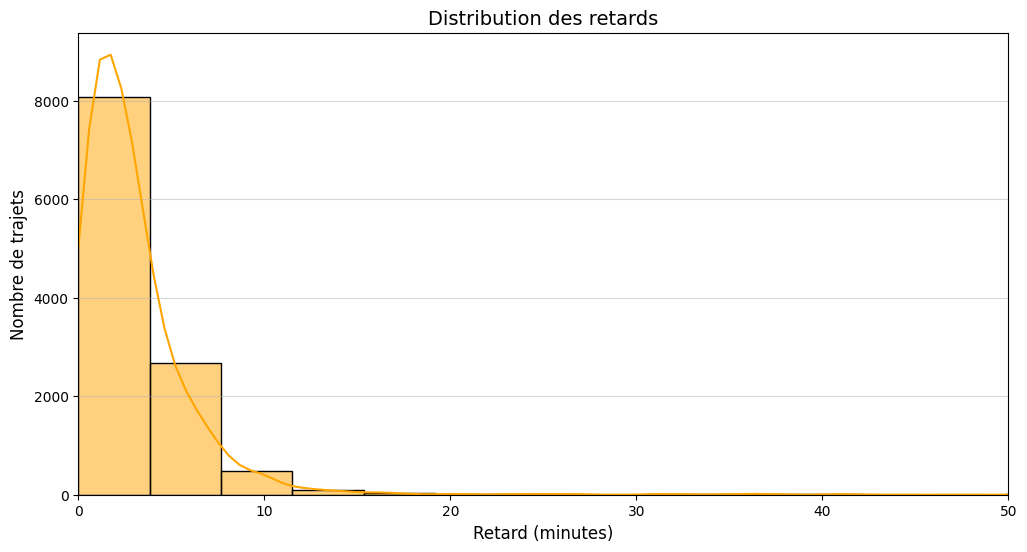

In [664]:
colonne_retard = "Retard moyen de tous les trains au départ"

# 1. Remplace les valeurs négatives par 0
df[colonne_retard] = df[colonne_retard].clip(lower=0)

# 2. Remplace les valeurs extrêmes (> 120 min) par la médiane
mediane = df[colonne_retard].median()
df[colonne_retard] = df[colonne_retard].apply(lambda x: mediane if x > 120 else x)

# 3. Arrondis les valeurs pour supprimer les décimales
df[colonne_retard] = df[colonne_retard].round().astype(int)

# 4. Vérifie le résultat
print(f"Nouveau minimum : {df[colonne_retard].min()}")
print(f"Nouveau maximum : {df[colonne_retard].max()}")

# 5. Refais la visualisation
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=colonne_retard, bins=30, kde=True, color='orange')
plt.title(f"Distribution des retards", fontsize=14)
plt.xlabel("Retard (minutes)", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xlim(0, 50)
plt.grid(axis='y', alpha=0.5)
plt.show()

Distribution des retards moyens de tous les trains à l'arrivée 

Nouveau minimum : 0
Nouveau maximum : 92


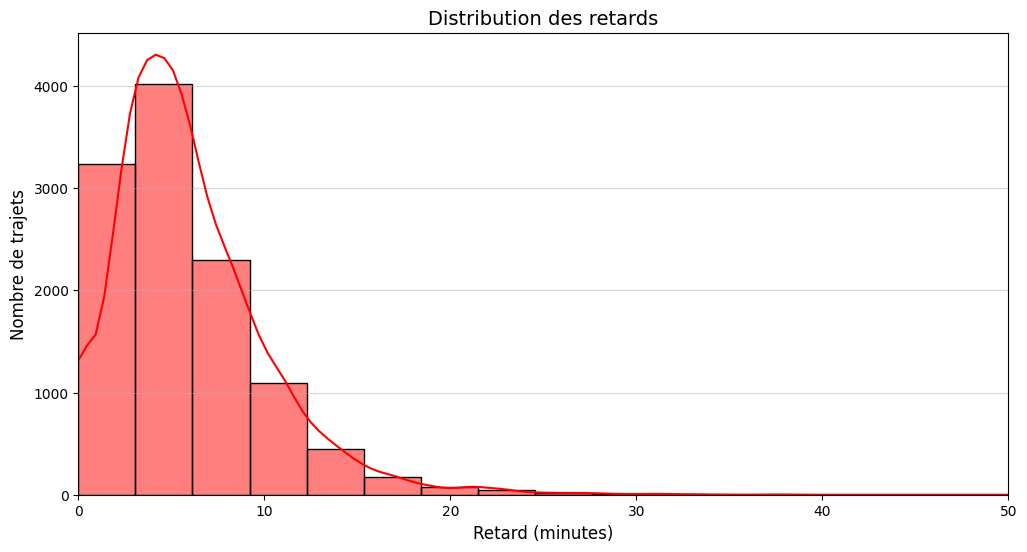

In [665]:
colonne_retard = "Retard moyen de tous les trains à l'arrivée"

# 1. Remplace les valeurs négatives par 0
df[colonne_retard] = df[colonne_retard].clip(lower=0)

# 2. Remplace les valeurs extrêmes (> 120 min) par la médiane
mediane = df[colonne_retard].median()
df[colonne_retard] = df[colonne_retard].apply(lambda x: mediane if x > 120 else x)

# 3. Arrondis les valeurs pour supprimer les décimales
df[colonne_retard] = df[colonne_retard].round().astype(int)

# 4. Vérifie le résultat
print(f"Nouveau minimum : {df[colonne_retard].min()}")
print(f"Nouveau maximum : {df[colonne_retard].max()}")

# 5. Refais la visualisation
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=colonne_retard, bins=30, kde=True, color='red')
plt.title(f"Distribution des retards", fontsize=14)
plt.xlabel("Retard (minutes)", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xlim(0, 50)
plt.grid(axis='y', alpha=0.5)
plt.show()

Nombre de trains en retard à l'arrivée 

Nombre de trains :
en_retard
1    10475
0      959
Name: count, dtype: int64


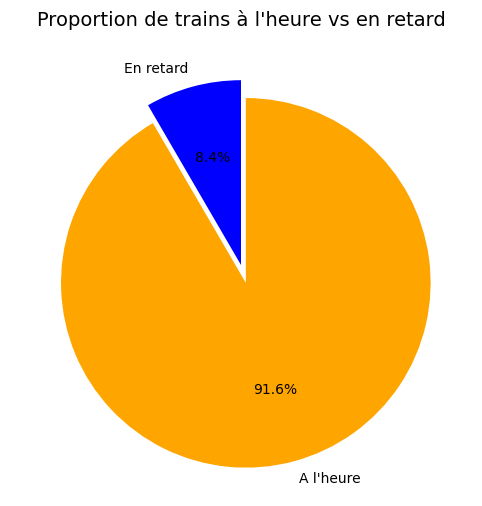

Pourcentage de trains en retard : 91.61%
Pourcentage de trains à l'heure : 8.39%


In [666]:

colonne_retard = "Retard moyen de tous les trains à l'arrivée"
df[colonne_retard] = df[colonne_retard].clip(lower=0)  

df["en_retard"] = (df[colonne_retard] > 1).astype(int)

# 3. Compte le nombre de trains à l'heure et en retard
retard_counts = df["en_retard"].value_counts()
print("Nombre de trains :")
print(retard_counts)

# 4. Trace le pie chart avec les bons labels
labels = ["En retard", "A l'heure"]
sizes = [retard_counts.get(0, 0), retard_counts.get(1, 0)]
colors = ["blue", "orange"]

plt.figure(figsize=(8, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.1)
)
plt.title("Proportion de trains à l'heure vs en retard", fontsize=14)
plt.show()

# 5. Affiche les pourcentages
total_trains = len(df)
pourcentage_retard = (retard_counts.get(1, 0) / total_trains) * 100
pourcentage_a_lheure = (retard_counts.get(0, 0) / total_trains) * 100

print(f"Pourcentage de trains en retard : {pourcentage_retard:.2f}%")
print(f"Pourcentage de trains à l'heure : {pourcentage_a_lheure:.2f}%")

In [667]:
nombre_total_trains = len(df)
print(f"Nombre de circulations prévues : {nombre_total_trains}")


Nombre de circulations prévues : 11434


In [668]:
colonne_service = "Service"
print(f"\nValeurs uniques dans '{colonne_service}' :")
print(df[colonne_service].unique())



Valeurs uniques dans 'Service' :
<StringArray>
['NATIONAL', 'INTERNATIONAL']
Length: 2, dtype: str



Nombre de trains en retard par type de service :
Service
NATIONAL         9234
INTERNATIONAL    1241
Name: count, dtype: int64


/tmp/ipykernel_39649/2546539074.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


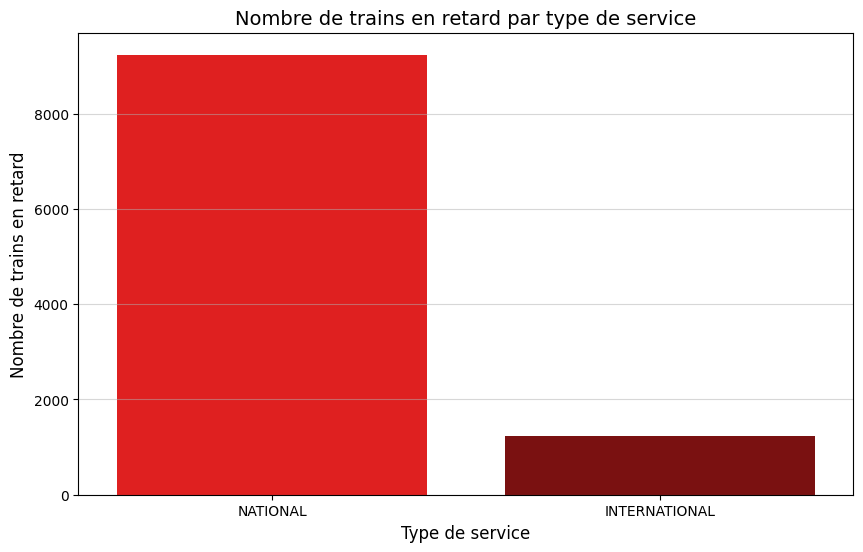

In [669]:
# Compte le nombre de trains en retard par type de service
nombre_retards_par_service = df[df["en_retard"] == 1][colonne_service].value_counts()
print("\nNombre de trains en retard par type de service :")
print(nombre_retards_par_service)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(
    x=nombre_retards_par_service.index,
    y=nombre_retards_par_service.values,
    palette=["red", "darkred"]
)
plt.title("Nombre de trains en retard par type de service", fontsize=14)
plt.xlabel("Type de service", fontsize=12)
plt.ylabel("Nombre de trains en retard", fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()


In [670]:
# 1. Vérifie les valeurs uniques
colonne_service = "Service"
print("Valeurs uniques :")
print(df[colonne_service].unique())

# 2. Nettoie les données
df[colonne_service] = df[colonne_service].str.lower()  # Standardise en minuscules
df[colonne_service] = df[colonne_service].replace({
    "nat": "national",
    "int": "international"
})

# 3. Compte les trains par catégorie
print("\nNombre de trains par type de service :")
print(df[colonne_service].value_counts(dropna=False))

# 4. Vérifie le total
total_calcule = df[colonne_service].value_counts().sum()
print(f"\nTotal calculé : {total_calcule} (vs {len(df)} trains dans le dataset)")

# 5. Filtre les lignes problématiques (si nécessaire)
df = df[df[colonne_service].isin(["national", "international"])]
print(f"\nTotal après filtrage : {len(df)}")


Valeurs uniques :
<StringArray>
['NATIONAL', 'INTERNATIONAL']
Length: 2, dtype: str

Nombre de trains par type de service :
Service
national         10022
international     1412
Name: count, dtype: int64

Total calculé : 11434 (vs 11434 trains dans le dataset)

Total après filtrage : 11434
